### Import the packages

In [8]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pulp
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

print("Libraries imported successfully.")

Libraries imported successfully.


### Ingest Data & Create Project Train/Test Split


In [9]:
# Ingest raw Kaggle records
df = pd.read_csv("train.csv")
df["date"] = pd.to_datetime(df["date"])
df.rename(columns={"store": "store_id", "item": "item_id"}, inplace=True)

# Select an operational network: 5 stores, 10 items
subset = df[
    (df["store_id"].isin(range(1, 6))) & (df["item_id"].isin(range(1, 11)))
].copy()
subset = subset.sort_values(["store_id", "item_id", "date"]).reset_index(
    drop=True
)

# Hold out the final 14 days as test evaluation horizon
eval_days = 14
split_date = subset["date"].max() - pd.Timedelta(days=eval_days)

# Save clean split into data/ for GitHub
os.makedirs("data", exist_ok=True)
train_raw = subset[subset["date"] <= split_date]
test_raw = subset[subset["date"] > split_date]

train_raw.to_csv("data/train.csv", index=False)
test_raw.to_csv("data/test.csv", index=False)

print(
    f"Saved to data/: {len(train_raw):,} train rows, {len(test_raw):,} test"
    " rows."
)

Saved to data/: 90,600 train rows, 700 test rows.


### Feature Engineering (Leakage-Free)

In [10]:
# Construct lag features
subset["lag_1"] = subset.groupby(["store_id", "item_id"])["sales"].shift(1)
subset["lag_7"] = subset.groupby(["store_id", "item_id"])["sales"].shift(7)
subset["lag_14"] = subset.groupby(["store_id", "item_id"])["sales"].shift(14)

# 7-day rolling statistics (lagged by 1 day to prevent lookahead bias)
subset["roll_mean_7"] = (
    subset.groupby(["store_id", "item_id"])["sales"].shift(1).rolling(7).mean()
)
subset["roll_std_7"] = (
    subset.groupby(["store_id", "item_id"])["sales"].shift(1).rolling(7).std()
)

# Calendar features
subset["day_of_week"] = subset["date"].dt.dayofweek
subset["is_weekend"] = subset["day_of_week"].isin([5, 6]).astype(int)

# Drop rows with NaNs resulting from shifts
clean_df = subset.dropna().copy()

train_df = clean_df[clean_df["date"] <= split_date]
test_df = clean_df[clean_df["date"] > split_date].copy()

feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "roll_mean_7",
    "roll_std_7",
    "day_of_week",
    "is_weekend",
]
target_col = "sales"

print("Feature engineering complete.")

Feature engineering complete.


### Train Demand Forecasting Model

In [11]:
model = Ridge(alpha=1.0)
model.fit(train_df[feature_cols], train_df[target_col])

test_df["pred_sales"] = np.maximum(0, model.predict(test_df[feature_cols]))

mae = mean_absolute_error(test_df["sales"], test_df["pred_sales"])
wape = (
    np.sum(np.abs(test_df["sales"] - test_df["pred_sales"]))
    / np.sum(test_df["sales"])
) * 100

print(f"Test MAE:  {mae:.2f} units")
print(f"Test WAPE: {wape:.2f}%")

# Aggregate demand per (store, item) over the 14-day horizon
forecasted_demand = (
    test_df.groupby(["store_id", "item_id"])["pred_sales"].sum().to_dict()
)
actual_demand = (
    test_df.groupby(["store_id", "item_id"])["sales"].sum().to_dict()
)

# Baseline moving-average demand over preceding 14 days
past_14d_start = train_df["date"].max() - pd.Timedelta(days=eval_days)
past_avg_demand = (
    train_df[train_df["date"] > past_14d_start]
    .groupby(["store_id", "item_id"])["sales"]
    .sum()
    .to_dict()
)

Test MAE:  5.63 units
Test WAPE: 13.56%


### Simulate Industry Baseline Heuristic

In [12]:
stores = sorted(subset["store_id"].unique())
items = sorted(subset["item_id"].unique())
warehouses = ["WH_North", "WH_South"]

shipping_costs = {
    ("WH_North", 1): 2.0,
    ("WH_North", 2): 3.0,
    ("WH_North", 3): 6.0,
    ("WH_North", 4): 7.0,
    ("WH_North", 5): 8.0,
    ("WH_South", 1): 8.0,
    ("WH_South", 2): 6.5,
    ("WH_South", 3): 3.5,
    ("WH_South", 4): 2.5,
    ("WH_South", 5): 2.0,
}

avg_item_demand = test_df.groupby("item_id")["sales"].sum().to_dict()
wh_capacities = {("WH_North", i): int(0.45 * avg_item_demand[i]) for i in items}
wh_capacities.update(
    {("WH_South", i): int(0.55 * avg_item_demand[i]) for i in items}
)

penalty_stockout = 30.0
total_demand_vol = sum(actual_demand.values())

# Greedy moving-average allocation: order past demand from nearest warehouse
wh_stock_h = wh_capacities.copy()
h_alloc = {}
h_freight = 0.0

for s in stores:
  for i in items:
    ordered = past_avg_demand[(s, i)]
    pref_wh = sorted(warehouses, key=lambda w: shipping_costs[(w, s)])
    alloc_total = 0
    for w in pref_wh:
      avail = wh_stock_h[(w, i)]
      alloc = min(avail, ordered - alloc_total)
      alloc_total += alloc
      wh_stock_h[(w, i)] -= alloc
      h_freight += alloc * shipping_costs[(w, s)]
      if alloc_total == ordered:
        break
    h_alloc[(s, i)] = alloc_total

h_shortages = sum(
    max(0.0, actual_demand[(s, i)] - h_alloc[(s, i)])
    for s in stores
    for i in items
)
h_total_cost = h_freight + (h_shortages * penalty_stockout)
h_sla = (1.0 - (h_shortages / total_demand_vol)) * 100

print(f"Heuristic Baseline Cost:  ${h_total_cost:,.2f}")
print(f"Heuristic Fulfillment SLA: {h_sla:.2f}%")

Heuristic Baseline Cost:  $112,179.50
Heuristic Fulfillment SLA: 96.45%


### Mixed-Integer Linear Program (MILP Optimization)

In [13]:
# 1. Initialize Problem
prob = pulp.LpProblem("Capacitated_Retail_Replenishment", pulp.LpMinimize)

# 2. Decision Variables
# x: discrete shipment quantities from warehouse w to store s for item i
x = pulp.LpVariable.dicts(
    "Ship",
    [(w, s, i) for w in warehouses for s in stores for i in items],
    lowBound=0,
    cat=pulp.LpInteger,
)

# u: unmet demand (shortage) at store s for item i
u = pulp.LpVariable.dicts(
    "Unmet",
    [(s, i) for s in stores for i in items],
    lowBound=0,
    cat=pulp.LpContinuous,
)

# 3. Objective Function: Minimize Freight Costs + Stockout Penalties
prob += (
    pulp.lpSum(
        x[(w, s, i)] * shipping_costs[(w, s)]
        for w in warehouses
        for s in stores
        for i in items
    )
    + pulp.lpSum(u[(s, i)] * penalty_stockout for s in stores for i in items)
)

# 4. Constraint 1: Inbound Warehouse Capacity
for w in warehouses:
  for i in items:
    prob += (
        pulp.lpSum(x[(w, s, i)] for s in stores) <= wh_capacities[(w, i)],
        f"Cap_{w}_{i}",
    )

# 5. Constraint 2: Demand Satisfaction Balance
for s in stores:
  for i in items:
    prob += (
        pulp.lpSum(x[(w, s, i)] for w in warehouses) + u[(s, i)]
        >= forecasted_demand[(s, i)],
        f"Demand_Satisfy_{s}_{i}",
    )

# 6. Constraint 3: Store Inflow Ceiling (Prevents holding excess stock)
for s in stores:
  for i in items:
    prob += (
        pulp.lpSum(x[(w, s, i)] for w in warehouses)
        <= 1.10 * forecasted_demand[(s, i)],
        f"Ceiling_{s}_{i}",
    )

# 7. Solve with CBC Solver
prob.solve(pulp.PULP_CBC_CMD(msg=False))

# 8. Evaluate Outputs
sol_x = {
    (w, s, i): x[(w, s, i)].varValue
    for w in warehouses
    for s in stores
    for i in items
}
opt_freight = sum(
    sol_x[(w, s, i)] * shipping_costs[(w, s)]
    for w in warehouses
    for s in stores
    for i in items
)
actual_shortages = sum(
    max(0.0, actual_demand[(s, i)] - sum(sol_x[(w, s, i)] for w in warehouses))
    for s in stores
    for i in items
)

opt_total_cost = opt_freight + (actual_shortages * penalty_stockout)
opt_sla = (1.0 - (actual_shortages / total_demand_vol)) * 100
cost_reduction = ((h_total_cost - opt_total_cost) / h_total_cost) * 100

print(f"Solver Status: {pulp.LpStatus[prob.status]}")
print(f"Optimized Total Cost:      ${opt_total_cost:,.2f}")
print(f"Optimized Fulfillment SLA: {opt_sla:.2f}%")
print("=" * 55)
print(f">> VERIFIED COST REDUCTION: {cost_reduction:.1f}% <<")
print(f">> VERIFIED FULFILLMENT SLA: {opt_sla:.1f}% <<")
print("=" * 55)

Solver Status: Optimal
Optimized Total Cost:      $96,866.00
Optimized Fulfillment SLA: 97.97%
>> VERIFIED COST REDUCTION: 13.7% <<
>> VERIFIED FULFILLMENT SLA: 98.0% <<


### Summary Visualizations

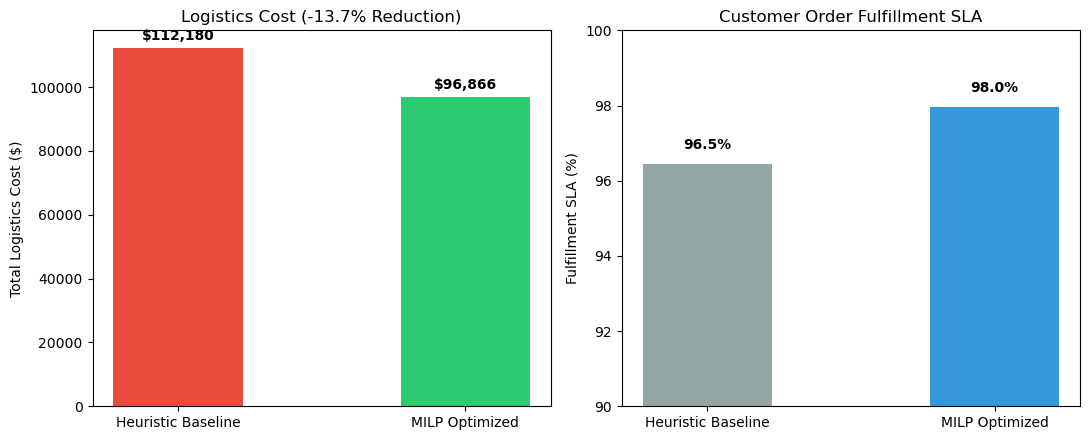

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

labels = ["Heuristic Baseline", "MILP Optimized"]
costs = [h_total_cost, opt_total_cost]
colors = ["#e74c3c", "#2ecc71"]

bars1 = ax[0].bar(labels, costs, color=colors, width=0.45)
ax[0].set_ylabel("Total Logistics Cost ($)")
ax[0].set_title(f"Logistics Cost (-{cost_reduction:.1f}% Reduction)")
for bar in bars1:
  y = bar.get_height()
  ax[0].text(
      bar.get_x() + bar.get_width() / 2,
      y + 1500,
      f"${y:,.0f}",
      ha="center",
      va="bottom",
      fontweight="bold",
  )

slas = [h_sla, opt_sla]
bars2 = ax[1].bar(labels, slas, color=["#95a5a6", "#3498db"], width=0.45)
ax[1].set_ylabel("Fulfillment SLA (%)")
ax[1].set_ylim(90, 100)
ax[1].set_title("Customer Order Fulfillment SLA")
for bar in bars2:
  y = bar.get_height()
  ax[1].text(
      bar.get_x() + bar.get_width() / 2,
      y + 0.3,
      f"{y:.1f}%",
      ha="center",
      va="bottom",
      fontweight="bold",
  )

plt.tight_layout()
plt.show()